In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Cấu hình giao diện Pastel
sns.set_theme(style="whitegrid", palette="pastel")
TITLE_COLOR = '#C44E52'



## Bước 1: Basic Cleaning & Multicollinearity
Loại bỏ lỗi, tính `usage_years` và xóa cột `year` gốc.


In [18]:
# Load Data đã được làm sạch bằng Power Query
df = pd.read_csv('CarsData_Cleaned.csv')

# 4. Feature Engineering: Tuổi xe
df['usage_years'] = df['year'].max() - df['year']
df = df.drop(columns=['year']) 

print("Shape dữ liệu sau làm sạch cơ bản:", df.shape)



Shape dữ liệu sau làm sạch cơ bản: (97542, 10)


## Bước 2: Xử lý Ngoại lai Toán học (IQR)
Cắt ngoại lai cho `mileage` và `mpg` (Bảo toàn `price` để giữ siêu xe). Trực quan hóa chứng minh ngoại lai đã bị dọn sạch.


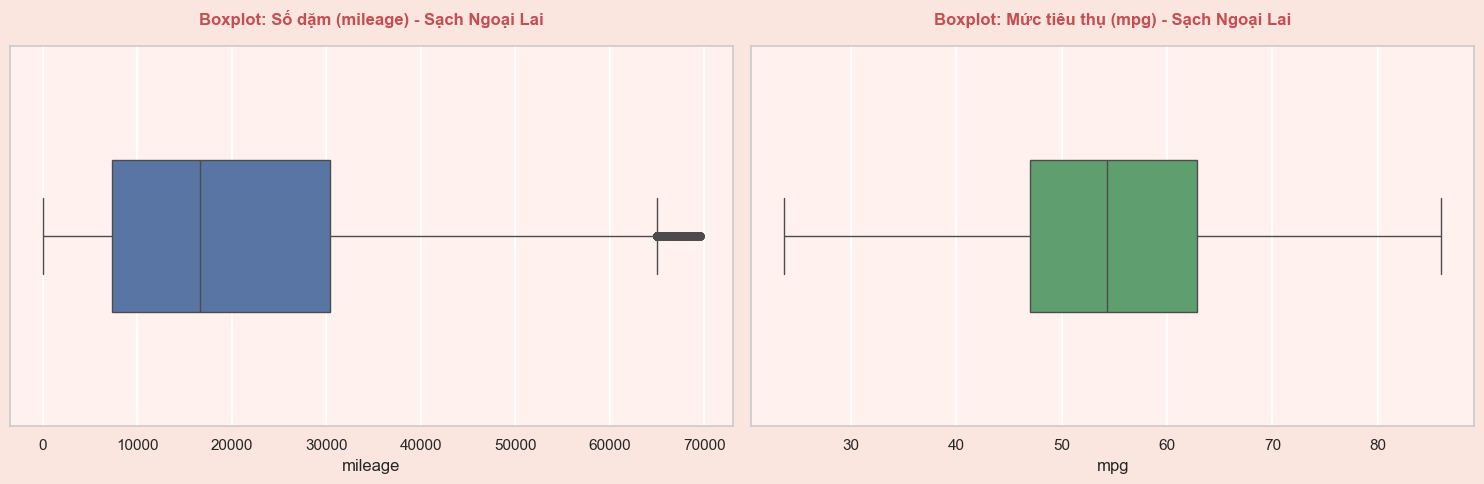

In [19]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

df = remove_outliers_iqr(df, 'mileage')
df = remove_outliers_iqr(df, 'mpg')

# --- TRỰC QUAN HÓA KIỂM CHỨNG ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#FAE5DF')
for ax in axes:
    ax.set_facecolor('#FFF1ED') 
    ax.grid(color='white', linestyle='-', linewidth=1.5)

sns.boxplot(x=df['mileage'], ax=axes[0], color='#4C72B0', width=0.4, fliersize=5)
axes[0].set_title('Boxplot: Số dặm (mileage) - Sạch Ngoại Lai', color=TITLE_COLOR, fontweight='bold', pad=15)

sns.boxplot(x=df['mpg'], ax=axes[1], color='#55A868', width=0.4, fliersize=5)
axes[1].set_title('Boxplot: Mức tiêu thụ (mpg) - Sạch Ngoại Lai', color=TITLE_COLOR, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



## Bước 3: Biến đổi phân phối (Data Transformation)
Sử dụng log1p để ép phân phối lệch phải của `price` và `mileage` về dạng hình chuông (Normal Distribution).


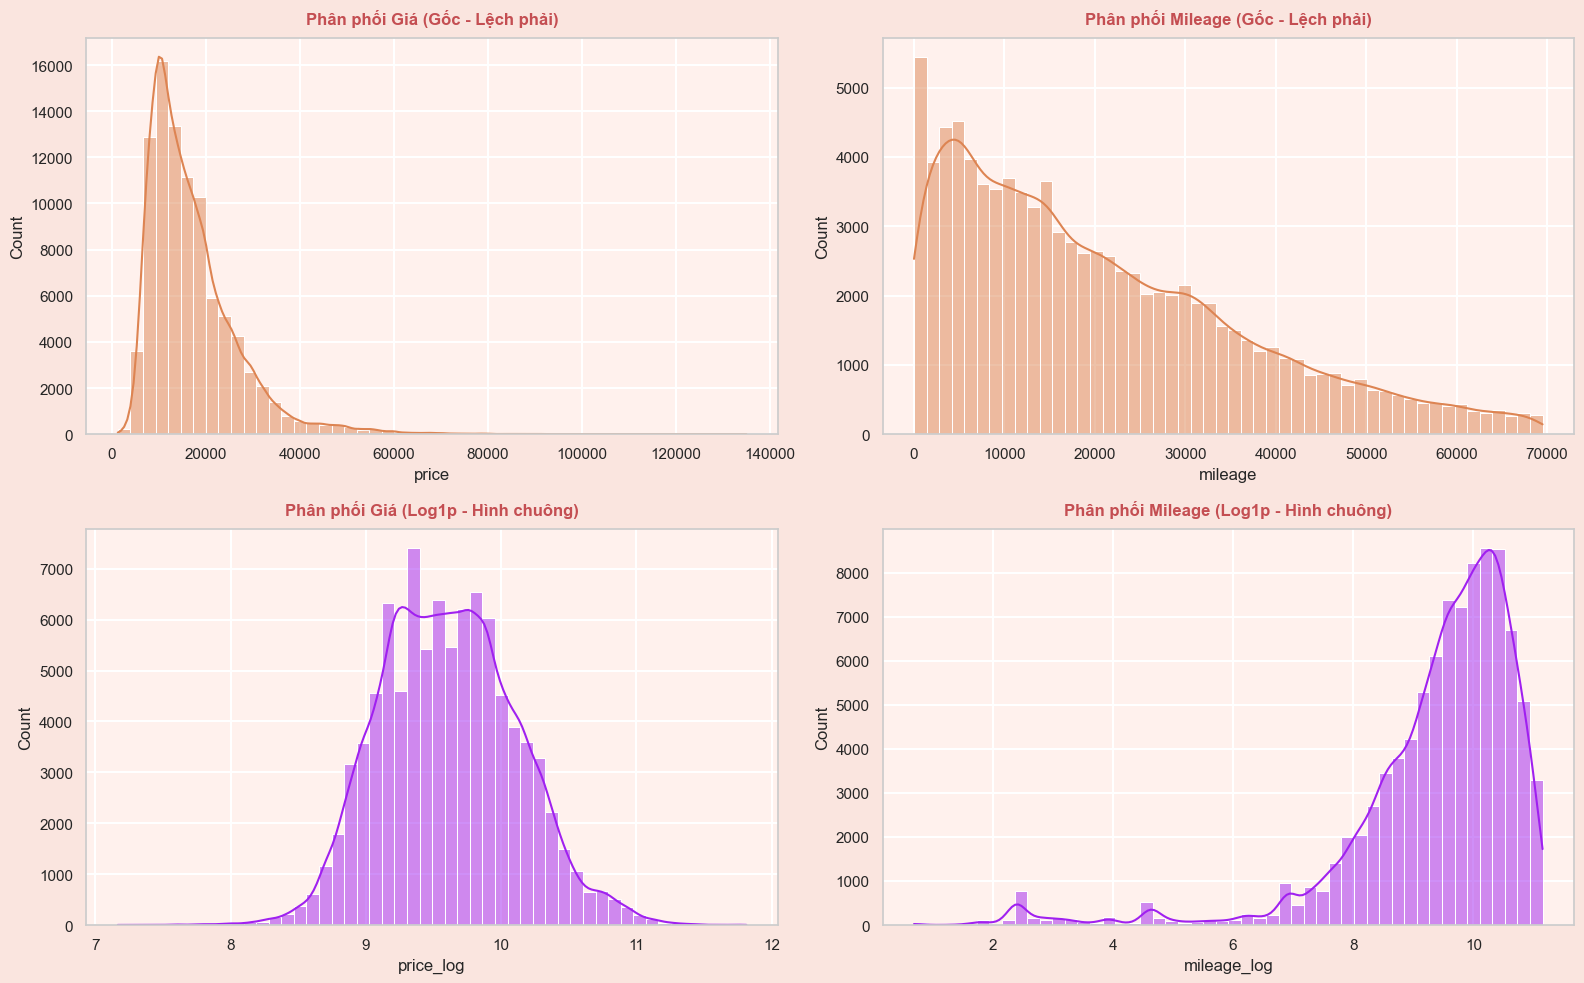

In [20]:
df['price_log'] = np.log1p(df['price'])
df['mileage_log'] = np.log1p(df['mileage'])

# --- TRỰC QUAN HÓA KIỂM CHỨNG ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#FAE5DF') # Màu nền pastel
for ax in axes.flat:
    ax.set_facecolor('#FFF1ED')
    ax.grid(color='white', linestyle='-', linewidth=1.5)

# Trước Transformation
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0, 0], color='#DD8452', edgecolor='white')
axes[0, 0].set_title('Phân phối Giá (Gốc - Lệch phải)', color=TITLE_COLOR, fontweight='bold', pad=10)
sns.histplot(df['mileage'], bins=50, kde=True, ax=axes[0, 1], color='#DD8452', edgecolor='white')
axes[0, 1].set_title('Phân phối Mileage (Gốc - Lệch phải)', color=TITLE_COLOR, fontweight='bold', pad=10)

# Sau Transformation (Log1p)
sns.histplot(df['price_log'], bins=50, kde=True, ax=axes[1, 0], color='#A020F0', edgecolor='white')
axes[1, 0].set_title('Phân phối Giá (Log1p - Hình chuông)', color=TITLE_COLOR, fontweight='bold', pad=10)
sns.histplot(df['mileage_log'], bins=50, kde=True, ax=axes[1, 1], color='#A020F0', edgecolor='white')
axes[1, 1].set_title('Phân phối Mileage (Log1p - Hình chuông)', color=TITLE_COLOR, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

# Giữ lại biến mục tiêu là price_log, xóa biến gốc
df = df.drop(columns=['price', 'mileage'])



In [21]:
df.head()

,model,transmission,fuelType,tax,mpg,engineSize,Manufacturer,usage_years,price_log,mileage_log
0,I10,Manual,Petrol,145,60.1,1.0,hyundai,3,8.922125,9.361429
1,Polo,Manual,Petrol,145,58.9,1.0,volkswagen,3,9.304741,9.127067
2,2Series,Semi-Auto,Diesel,145,49.6,2.0,BMW,1,10.239638,7.387090
3,YetiOutdoor,Manual,Diesel,150,62.8,2.0,skoda,3,9.433164,10.340484
4,Fiesta,Manual,Petrol,125,54.3,1.2,ford,3,8.987197,9.870654


## Bước 4. Tiền xử lí đặc trưng (Data Preprocessing)
- Tách biến đầu vào và biến mục tiêu
- Chia tập huấn luyện và kiểm tra
- Xác định các thuộc tính số và thuộc tính phân loại
- Chuẩn hóa dữ liệu số bằng StandardScaler
- Mã hóa dữ liệu phân loại bằng OneHotEncoder và OrdinalEncoder tùy theo mô hình Linear hay Tree
- Xây dựng bộ tiền xử lý bằng ColumnTransformer

In [22]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

df_model = df.copy()

X = df_model.drop(columns=['price_log'])
y = df_model['price_log']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

cat_cols = ['model','Manufacturer','transmission','fuelType']

num_cols = [col for col in X.columns if col not in cat_cols ]


linear_preprocessor = ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
])

tree_preprocessor = ColumnTransformer([
    ('cat',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1),
     cat_cols)], remainder='passthrough')




## Bước 5. Model Training Set up
Đóng gói các mô hình với các preprocessor tương ứng với mô hình đó.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

models = {
    'Linear': Pipeline([('prep', linear_preprocessor), 
                        ('model', LinearRegression())
                        ]),

    'Decision Tree': Pipeline([('prep', tree_preprocessor),
                               ('model', DecisionTreeRegressor(
                                   max_depth=10,
                                   min_samples_leaf=5,
                                   random_state=42))
                                   ]),

    'Random Forest': Pipeline([('prep', tree_preprocessor),
                               ('model', RandomForestRegressor(
                                   n_estimators=300,
                                   max_depth=15,
                                   min_samples_leaf=3,
                                   n_jobs=-1,
                                   random_state=42))
                                   ]),

    'XGBoost': Pipeline([('prep', tree_preprocessor),
                         ('model', XGBRegressor(
                             n_estimators=500,
                             learning_rate=0.05,
                             max_depth=6,
                             subsample=0.8,
                             colsample_bytree=0.8,
                             random_state=42))
                             ])
}


## Bước 6: Huấn luyện và đánh giá mô hình (Model Training & Evaluation)


In [24]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': mean_squared_error(y_test,y_pred)**0.5,
        'R2': r2_score(y_test,y_pred)
        })


cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_seed=42
)

cat_train = X_train.copy()
cat_test = X_test.copy()

cat_index = [cat_train.columns.get_loc(c) for c in cat_cols]

cat_model.fit(cat_train, y_train, cat_features=cat_index)

cat_pred = cat_model.predict(cat_test)
results.append({
    'Model':'CatBoost',
    'MAE': mean_absolute_error(y_test, cat_pred),
    'RMSE': mean_squared_error(y_test, cat_pred)**0.5,
    'R2':r2_score(y_test, cat_pred)
})

result_df = pd.DataFrame(results)

print(result_df.sort_values('R2',ascending=False))

           Model       MAE      RMSE        R2
3        XGBoost  0.070166  0.093068  0.965774
2  Random Forest  0.070088  0.096737  0.963022
4       CatBoost  0.079206  0.103747  0.957469
0         Linear  0.098626  0.129175  0.934066
1  Decision Tree  0.108277  0.144295  0.917728


## Bước 7: Trực quan hóa mô hình

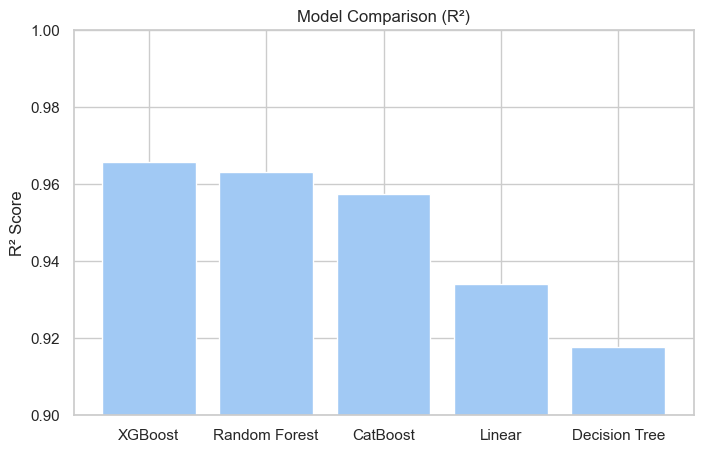

In [25]:
result_df = result_df.sort_values('R2', ascending=False)

plt.figure(figsize=(8,5))

plt.bar(result_df['Model'], result_df['R2'])

plt.title('Model Comparison (R²)')
plt.ylabel('R² Score')
plt.ylim(0.9,1)

plt.show()

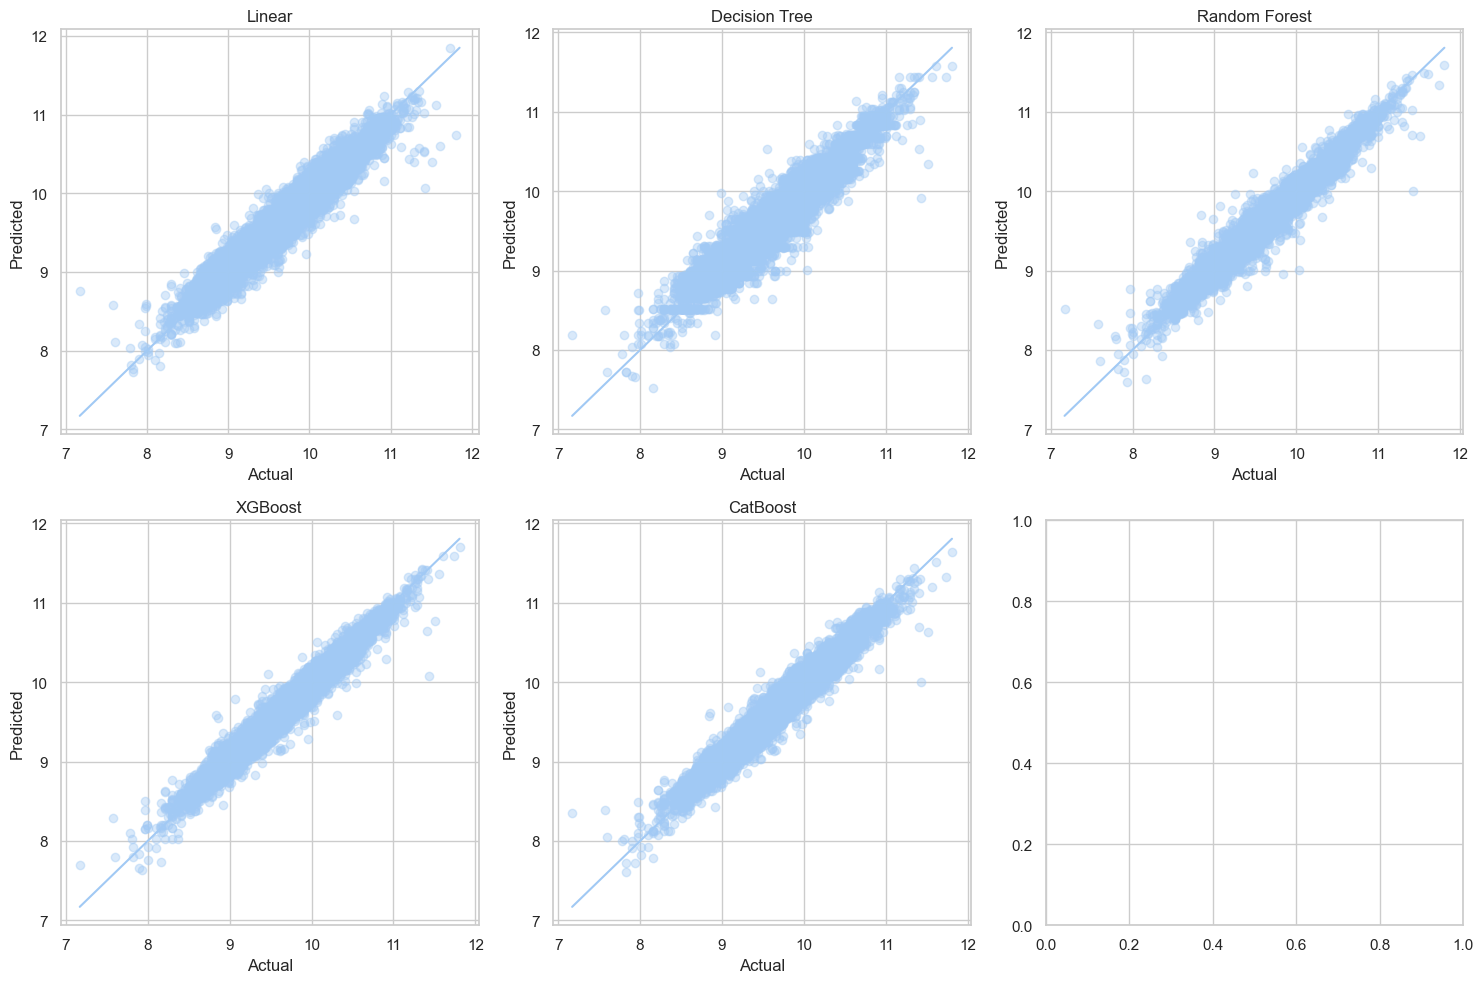

In [26]:
all_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    all_models[name] = pred

cat_model.fit(cat_train, y_train, cat_features=cat_index)

all_models['CatBoost'] = cat_model.predict(cat_test)


fig, axes = plt.subplots(2, 3, figsize=(15,10))

axes = axes.flatten()
for ax, (name, pred) in zip(axes, all_models.items()):
    ax.scatter(y_test, pred, alpha=0.4)

    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())

    ax.plot([min_val, max_val], [min_val, max_val])

    ax.set_title(f'{name}')

    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

In [27]:
final_model = Pipeline([
    ('prep', tree_preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

final_model.fit(X,y)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
import joblib

joblib.dump(final_model, "car_price_predictor.pkl")

['car_price_predictor.pkl']

In [31]:
df.head()

,model,transmission,fuelType,tax,mpg,engineSize,Manufacturer,usage_years,price_log,mileage_log
0,I10,Manual,Petrol,145,60.1,1.0,hyundai,3,8.922125,9.361429
1,Polo,Manual,Petrol,145,58.9,1.0,volkswagen,3,9.304741,9.127067
2,2Series,Semi-Auto,Diesel,145,49.6,2.0,BMW,1,10.239638,7.387090
3,YetiOutdoor,Manual,Diesel,150,62.8,2.0,skoda,3,9.433164,10.340484
4,Fiesta,Manual,Petrol,125,54.3,1.2,ford,3,8.987197,9.870654
